Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import cross_val_score, GridSearchCV, learning_curve

sns.set_theme(style='whitegrid')
os.makedirs('../outputs/figures', exist_ok=True)
print("Imports successful")

Imports successful


Load Data & Models

In [ ]:
X_train = np.load('../data/processed/X_train.npy')
X_test  = np.load('../data/processed/X_test.npy')
y_train = np.load('../data/processed/y_train.npy')
y_test  = np.load('../data/processed/y_test.npy')

FEATURES = joblib.load('../outputs/models/feature_names.pkl')

lr  = joblib.load('../outputs/models/linear_regression.pkl')
rf  = joblib.load('../outputs/models/random_forest.pkl')
xgb = joblib.load('../outputs/models/xgboost.pkl')

print("Data and models loaded successfully")

Data and models loaded successfully


Cross Validation (5-Fold)


In [ ]:
models = {
    'Linear Regression': lr,
    'Random Forest'    : rf,
    'XGBoost'          : xgb
}

print("=== 5-Fold Cross Validation (R²) ===\n")
cv_results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring='r2', n_jobs=-1)
    cv_results[name] = scores
    print(f"{name}")
    print(f"  Scores : {np.round(scores, 4)}")
    print(f"  Mean R²: {scores.mean():.4f}")
    print(f"  Std    : {scores.std():.4f}\n")

=== 5-Fold Cross Validation (R²) ===

Linear Regression
  Scores : [0.3888 0.4181 0.3781 0.3657 0.3793]
  Mean R²: 0.3860
  Std    : 0.0177



Random Forest
  Scores : [0.5743 0.6098 0.5979 0.5661 0.6149]
  Mean R²: 0.5926
  Std    : 0.0193

XGBoost
  Scores : [0.5663 0.5973 0.5829 0.558  0.6016]
  Mean R²: 0.5812
  Std    : 0.0170



Cross Validation Plot

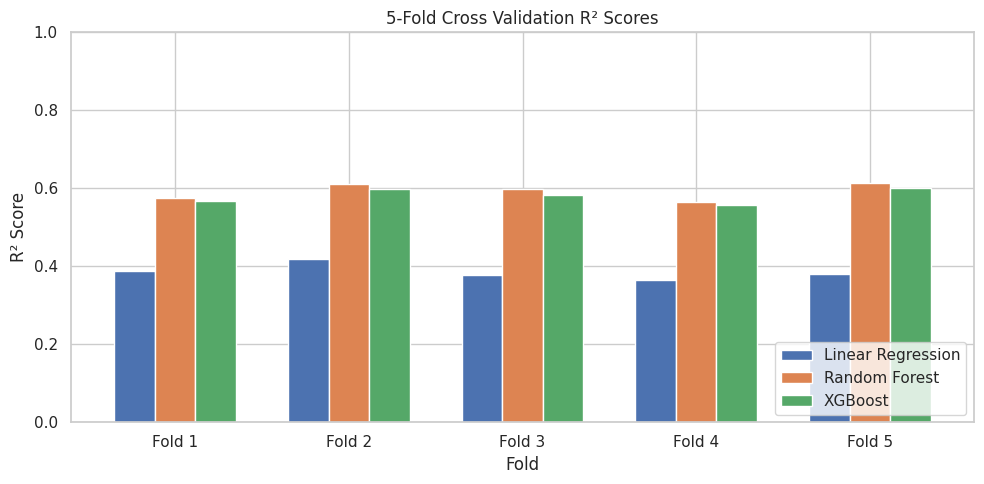

In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
cv_df = pd.DataFrame(cv_results)
cv_df.index = [f'Fold {i+1}' for i in range(5)]

cv_df.plot(kind='bar', ax=ax, width=0.7)
ax.set_title('5-Fold Cross Validation R² Scores')
ax.set_xlabel('Fold')
ax.set_ylabel('R² Score')
ax.legend(loc='lower right')
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/cross_validation.png', dpi=150)
plt.show()

Hyperparameter Tuning (Random Forest)


In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth'   : [5, 10, 15],
    'min_samples_split': [2, 5]
}

grid_rf = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_rf.fit(X_train, y_train)

print(f"Best params : {grid_rf.best_params_}")
print(f"Best CV R²  : {grid_rf.best_score_:.4f}")

# Save tuned model
rf_tuned = grid_rf.best_estimator_
joblib.dump(rf_tuned, '../outputs/models/random_forest_tuned.pkl')

Fitting 5 folds for each of 18 candidates, totalling 90 fits
Best params : {'max_depth': 10, 'min_samples_split': 5, 'n_estimators': 200}
Best CV R²  : 0.5937


['../outputs/models/random_forest_tuned.pkl']

Hyperparameter Tuning (XGBoost)


In [ ]:
param_grid_xgb = {
    'n_estimators' : [50, 100, 200],
    'max_depth'    : [3, 6, 9],
    'learning_rate': [0.01, 0.1, 0.2]
}

grid_xgb = GridSearchCV(
    XGBRegressor(random_state=42, verbosity=0),
    param_grid_xgb,
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)
grid_xgb.fit(X_train, y_train)

print(f"Best params : {grid_xgb.best_params_}")
print(f"Best CV R²  : {grid_xgb.best_score_:.4f}")

xgb_tuned = grid_xgb.best_estimator_
joblib.dump(xgb_tuned, '../outputs/models/xgboost_tuned.pkl')

Fitting 5 folds for each of 27 candidates, totalling 135 fits


Best params : {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 100}
Best CV R²  : 0.5969


['../outputs/models/xgboost_tuned.pkl']

Final Evaluation (All Models Including Tuned)


In [ ]:
def evaluate(name, model, X_test, y_test):
    pred = model.predict(X_test)
    return {
        'Model': name,
        'MAE'  : round(mean_absolute_error(y_test, pred), 2),
        'RMSE' : round(np.sqrt(mean_squared_error(y_test, pred)), 2),
        'R²'   : round(r2_score(y_test, pred), 4)
    }, pred

results = []
preds   = {}

for name, model in {
    'Linear Regression'  : lr,
    'Random Forest'      : rf,
    'Random Forest Tuned': rf_tuned,
    'XGBoost'            : xgb,
    'XGBoost Tuned'      : xgb_tuned
}.items():
    r, p     = evaluate(name, model, X_test, y_test)
    results.append(r)
    preds[name] = p

results_df = pd.DataFrame(results).sort_values('R²', ascending=False).reset_index(drop=True)
results_df.index += 1
print("=== Final Model Comparison ===")
print(results_df.to_string())

=== Final Model Comparison ===
                 Model      MAE      RMSE      R²
1  Random Forest Tuned  6079.08   8253.36  0.5941
2        XGBoost Tuned  6186.69   8263.83  0.5930
3        Random Forest  6092.16   8266.21  0.5928
4              XGBoost  6253.35   8392.79  0.5802
5    Linear Regression  7886.13  10174.83  0.3830


Final Comparison Bar Chart

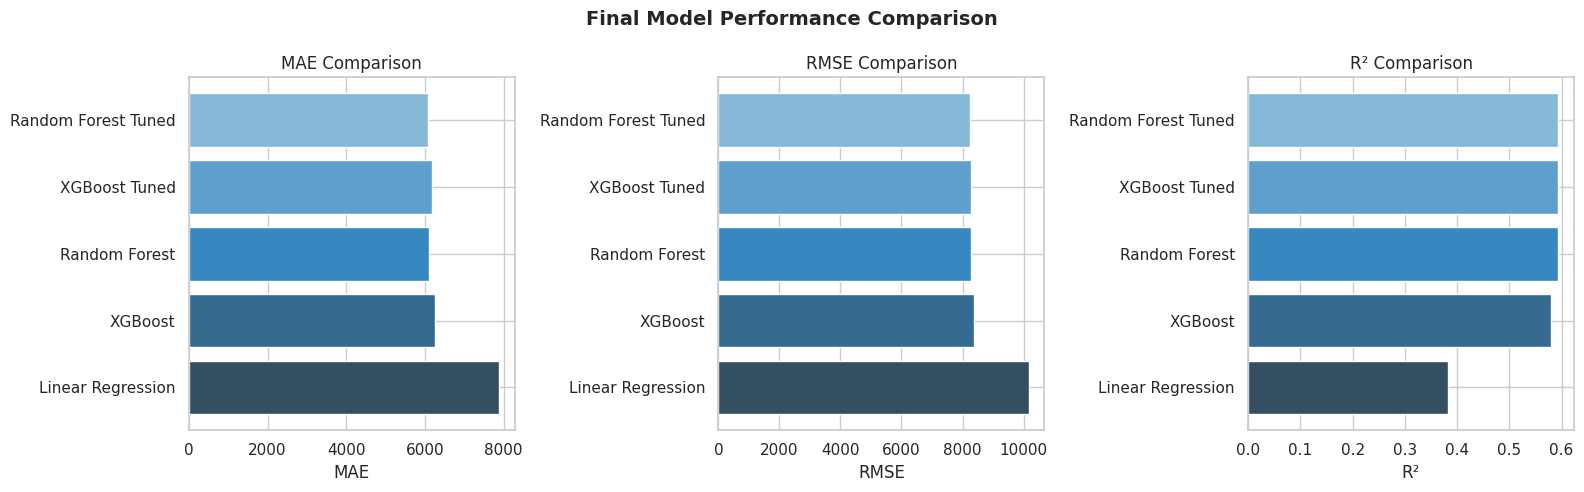

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
metrics = ['MAE', 'RMSE', 'R²']
palette = sns.color_palette('Blues_d', len(results_df))

for i, metric in enumerate(metrics):
    axes[i].barh(results_df['Model'], results_df[metric], color=palette)
    axes[i].set_title(f'{metric} Comparison')
    axes[i].set_xlabel(metric)
    axes[i].invert_yaxis()

plt.suptitle('Final Model Performance Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/figures/final_model_comparison.png', dpi=150)
plt.show()

Best Model

In [ ]:
best_name      = results_df.iloc[0]['Model']
best_model_obj = {
    'Linear Regression'  : lr,
    'Random Forest'      : rf,
    'Random Forest Tuned': rf_tuned,
    'XGBoost'            : xgb,
    'XGBoost Tuned'      : xgb_tuned
}[best_name]

print(f"Best model: {best_name}")


Best model: Random Forest Tuned


Demo Prediction

In [ ]:
scaler   = joblib.load('../outputs/models/scaler.pkl')
le_area  = joblib.load('../outputs/models/le_area.pkl')

print("=== Available Areas ===")
for i, area in enumerate(le_area.classes_):
    print(f"  {i} = {area}")

=== Available Areas ===
  0 = Electronic City
  1 = Hebbal
  2 = Indiranagar
  3 = Jayanagar
  4 = Koramangala
  5 = M.G. Road
  6 = Whitefield
  7 = Yeshwanthpur


Run Demo Prediction

In [ ]:
sample = pd.DataFrame([{
    'Area Name'                          : 2,    # change based on Cell 11 output
    'Average Speed'                      : 35.0,
    'Travel Time Index'                  : 1.5,
    'Congestion Level'                   : 75.0,
    'Road Capacity Utilization'          : 80.0,
    'Incident Reports'                   : 1,
    'Public Transport Usage'             : 40.0,
    'Traffic Signal Compliance'          : 78.0,
    'Parking Usage'                      : 55.0,
    'Pedestrian and Cyclist Count'       : 200,
    'Weather Conditions'                 : 1,
    'Roadwork and Construction Activity' : 0,
    'month'                              : 4,
    'day_of_week'                        : 1,
    'day'                                : 14,
    'is_weekend'                         : 0,
    'quarter'                            : 2
}])

sample_scaled = scaler.transform(sample)
prediction    = best_model_obj.predict(sample_scaled)

print(f"Input area          : {le_area.classes_[2]}")
print(f"Predicted traffic   : {int(prediction[0])} vehicles")
print(f"Model used          : {best_name}")

ValueError: The feature names should match those that were passed during fit.
Feature names unseen at fit time:
- Congestion Level
- Road Capacity Utilization
- Travel Time Index


Save Final Best Model for Flask


In [ ]:
joblib.dump(best_model_obj, '../outputs/models/best_model.pkl')

print("=== Project Complete — ML Side ===")
print(f"Best model          : {best_name}")
print(f"Saved to            : outputs/models/best_model.pkl")
print(f"\nFiles ready for Flask:")
print(f"  - outputs/models/best_model.pkl")
print(f"  - outputs/models/scaler.pkl")
print(f"  - outputs/models/le_area.pkl")
print(f"  - outputs/models/le_weather.pkl")
print(f"  - outputs/models/le_road.pkl")
print(f"  - outputs/models/feature_names.pkl")
print(f"\nFigures saved for report:")
for f in os.listdir('../outputs/figures'):
    print(f"  - outputs/figures/{f}")

=== Project Complete — ML Side ===
Best model          : Random Forest Tuned
Saved to            : outputs/models/best_model.pkl

Files ready for Flask:
  - outputs/models/best_model.pkl
  - outputs/models/scaler.pkl
  - outputs/models/le_area.pkl
  - outputs/models/le_weather.pkl
  - outputs/models/le_road.pkl
  - outputs/models/feature_names.pkl

Figures saved for report:
  - outputs/figures/correlation_heatmap.png
  - outputs/figures/traffic_by_day.png
  - outputs/figures/traffic_by_area.png
  - outputs/figures/model_comparison.png
  - outputs/figures/traffic_by_hour.png
  - outputs/figures/actual_vs_predicted.png
  - outputs/figures/cross_validation.png
  - outputs/figures/final_model_comparison.png
  - outputs/figures/feature_importance.png
